In [1]:
from Libraries import *
from Diagram_Call import *




2024-04-08 09:21:38.673468: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-08 09:21:38.673546: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-08 09:21:38.673601: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-08 09:21:38.688260: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
#select a random number between 0 and 1  using numpy
for i in range(100):
    print(np.random.rand())



0.4440657178816406
0.44181311799186584
0.11767817640788436
0.7658567888241976
0.5657429951397734
0.581257151727253
0.9749980789110619
0.560317735112047
0.5630721744229014
0.11343470315475745
0.5890600701551233
0.780775786759986
0.9401025514963431
0.11594166011608065
0.5671733333044467
0.11073011831332069
0.40970861696145
0.35435934567651783
0.05563968926844054
0.23139970052251946
0.06425503038338798
0.08065977198382013
0.09694893885777345
0.7467136108268358
0.3930966935415102
0.43254976780285637
0.2597658202497741
0.6723832246201639
0.9560129865574101
0.4956922498116104
0.8563033473003234
0.1300561755862243
0.9374573904835369
0.340335198229623
0.9731934621730018
0.8673219635126318
0.2480083619919281
0.41516348090804556
0.3410161431132471
0.23808964714291247
0.9587371962760496
0.6462224311354976
0.4265626280666456
0.6212924656574421
0.6448950987792519
0.25217206994936026
0.21084902145759166
0.791059116538482
0.9457111744502678
0.3505376800933201
0.12720196843643872
0.9674231979742163
0.

In [2]:


LOOKBACK = 6 # History given as input to the network. Could be modified if needed
GAMMA = 2 # Positive slope of the loss function
NUM_SERV_B1 = 5 # number of services for the block 1
NUM_SERV_H = 1 # number of services for the helper
B = 100 # Number of montecarlo output
SEL_SERVS=[0, 1, 2, 3, 4] #Services to be selected for Helper Block


# PHIS = [0.1,1,10] # Negative slope of the loss function TO BE MODIFIED 
PHI = 0.1

# cities = ['Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
        # 'Nice', 'Paris','Reims', 'Rennes', 'Strasbourg'] ## Bordeaux and Toulouse are not included in the dataset 

# cities = ['Strasbourg']
city = 'Paris'
ALPHA=2
# ALPHAS=[2]

save=True

DELAY_Block1_Block2 = None # Lenght forecasted by the network. Could be modified if needed
DELAY_Helper = 1 # Lenght forecasted by the network. Could be modified if needed
EPOCHS_block1 = 300 # Number of epochs for the block 1
EPOCHS_block2 = 500 # Number of epochs for the block 2
EPOCHS_Helper = 300 # Number of epochs for the helper
Simulations= 1 # Number of simulations for the optimal window selection


# TB_Fpath = 'Training_Block_Optimal_Cities_test_kr_ki'
# save_folder = 'Results_Optimal_Cities_test_kr_ki'
save_folder = 'Results_Optimal_Cities_test_kr_ki_ALLOC_changed_b2'

pair_list=[]
ppf_static_list=[0.9]
# ppf_static_list=[0.9]
ppf_helper_list=[0.7]

# ETAS =[1,2,10,20,30,40,50,70,90,100]
ETA = 100
n_simulation = 1

In [3]:
config=dl.get_config(city,ETA, LOOKBACK, DELAY_Block1_Block2,DELAY_Helper, PHI, GAMMA, NUM_SERV_B1,NUM_SERV_H,SEL_SERVS,
    EPOCHS_block1,EPOCHS_block2,EPOCHS_Helper, B,ALPHA,n_simulation,ppf_helper=ppf_helper_list,ppf_static=ppf_static_list)


In [4]:



city=config['city'] 
LOOKBACK=config['LOOKBACK']
DELAY=config['DELAY_Block1_Block2']  
PHI=config['PHI']
GAMMA=config['GAMMA']
EPOCHS=config['EPOCHS_block2']
B=config['B']
ALPHA=config['ALPHA']
ppf_helper=config['ppf_helper']
ppf_static=config['ppf_static']
ETA = config['ETA']

DIR = '.'
DELAY = 85


In [5]:
def cost_func(y_true, y_pred, alpha, delay, gamma):
            step = alpha
            forecast_delay = delay
            #delta_x = 0.05
            epsilon = -step / 0.1
            y_pred = tf.expand_dims(y_pred, axis=1)
            y_pred = tf.tile(y_pred, (1, forecast_delay, 1))
            cost = y_pred - y_true# - delta_x
            big_penalty = epsilon * (cost + 0.1) + step
            penalty = -0.1 * (cost + 0.1) + step
            pen_positive = cost * gamma
            cost = tf.where(cost > 0, pen_positive, cost)
            cost = tf.where(cost < -0.1, penalty, cost)
            cost = tf.where(tf.logical_and((cost <= 0), (cost >= -0.1)),
                            big_penalty, cost)
            cost = tf.abs(cost)
            cost = K.sum(K.sum(cost, axis=-1), axis=-1)
            cost= K.mean(cost) ## ADDED NOW, Maybe remove it
            return cost

In [6]:
DIR= '/home/sergi_alcala/'

In [7]:
    ## Load Data
bordeaux = pd.read_csv(f'{DIR}/sergi_data/AZTEC_extension/citys/{city}.csv')
bordeaux.drop('date_time', axis=1, inplace=True)
bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
bordeaux = bordeaux.to_numpy()

    ##Load Normalization
normalizator = pickle.load(open(f'{DIR}/sergi_data/AZTEC_extension/{save_folder}/{city}/PHI_{PHI}/ETA_{ETA}/Th_{DELAY}/block_1_minmaxscaler.pkl', 'rb'))

    ##Transpose Data
helper_forecasting_training = np.transpose(
    np.load(f'{DIR}/sergi_data/AZTEC_extension/{save_folder}/{city}/helper_training_forecasting_delay_1.npy'), (0, 2, 1))
helper_forecasting_test = np.transpose(np.load(f'{DIR}/sergi_data/AZTEC_extension/{save_folder}/{city}/helper_forecasting_delay_1.npy'),
                                    (0, 2, 1))

# MinMaxScaler normalize between 0 and 1
helper_forecasting_training = helper_forecasting_training.clip(min=0)
helper_forecasting_test = helper_forecasting_test.clip(min=0)

dist_help_training = scipy.stats.norm(loc=helper_forecasting_training.mean(axis=-1),
                                    scale=helper_forecasting_training.std(axis=-1))
dist_help_test = scipy.stats.norm(loc=helper_forecasting_test.mean(axis=-1),
                                scale=helper_forecasting_test.std(axis=-1))

upper_help_training = dist_help_training.ppf(ppf_helper) ## Remember that you can modify these values
upper_help_test = dist_help_test.ppf(ppf_helper) ## Remember that you can modify these values

upper_help_training[np.where(np.isnan(upper_help_training))] = (
    helper_forecasting_training[np.where(np.isnan(upper_help_training))][:, 1])
upper_help_test[np.where(np.isnan(upper_help_test))] = (
    helper_forecasting_test[np.where(np.isnan(upper_help_test))][:, 1])



In [8]:



static_training = np.load(f'{DIR}/sergi_data/AZTEC_extension/{save_folder}/{city}/PHI_{PHI}/ETA_{ETA}/Th_{DELAY}/cap_fore_uncer_training_block1_delay_{DELAY}_phi_{PHI}_gamma_2_deltax_005.npy')
static_test = np.load(f'{DIR}/sergi_data/AZTEC_extension/{save_folder}/{city}/PHI_{PHI}/ETA_{ETA}/Th_{DELAY}/cap_fore_uncer_test_block1_delay_{DELAY}_phi_{PHI}_gamma_2_deltax_005.npy')

# MinMaxScaler normalize between 0 and 1
static_training = static_training.clip(min=0)
static_test = static_test.clip(min=0)

dist_static_training = scipy.stats.norm(loc=static_training.mean(axis=-1),
                                        scale=static_training.std(axis=-1))
dist_static_test = scipy.stats.norm(loc=static_test.mean(axis=-1),
                                    scale=static_test.std(axis=-1))

upper_static_training = dist_static_training.ppf(ppf_static) ## Remember that you can modify these values
upper_static_test = dist_static_test.ppf(ppf_static) ## Remember that you can modify these values


upper_static_training[np.where(np.isnan(upper_static_training))] = (
    static_training[np.where(np.isnan(upper_static_training))][:, 0])
upper_static_test[np.where(np.isnan(upper_static_test))] = (
    static_test[np.where(np.isnan(upper_static_test))][:, 0])
    

In [9]:

diff = min(upper_static_training.shape[0], upper_help_training.shape[0])
upper_static_training_diff = upper_static_training.shape[0] - diff
upper_help_training_diff = upper_help_training.shape[0] - diff




upper_static_training_diff = upper_static_training.shape[0] - diff
upper_help_training_diff = upper_help_training.shape[0] - diff




if upper_static_training_diff != 0:
    upper_static_training = upper_static_training[upper_static_training_diff:]
if upper_help_training_diff != 0:
    upper_help_training = upper_help_training[upper_help_training_diff:]

diff = min(upper_static_test.shape[0], upper_help_test.shape[0])
upper_static_test_diff = upper_static_test.shape[0] - diff
upper_help_test_diff = upper_help_test.shape[0] - diff


if upper_static_test_diff != 0:
    upper_static_test = upper_static_test[upper_static_test_diff:]
if upper_help_test_diff != 0:
    upper_help_test = upper_help_test[upper_help_test_diff:]

In [16]:
import matplotlib.pyplot as plt

In [17]:
start = 0
end = 2000

In [18]:
upper_help_training.shape

(14280, 5)

In [19]:
upper_static_training.shape

(14280, 5)

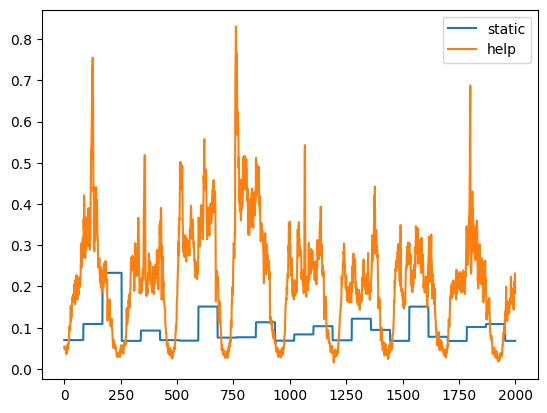

In [20]:
plt.plot(upper_static_training[start:end,0], label = 'static')
plt.plot(upper_help_training[start:end,0], label = 'help')
plt.legend()

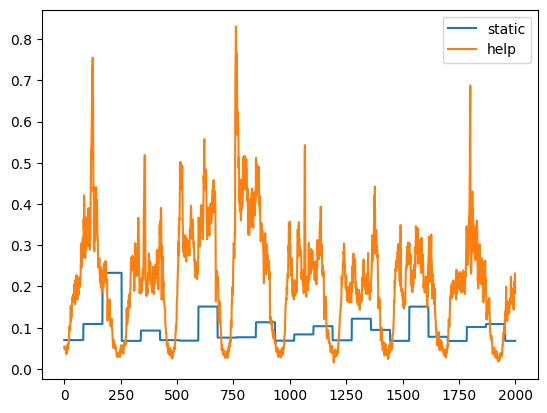

In [21]:
plt.plot(upper_static_training[start:end,0], label = 'static')
plt.plot(upper_help_training[start:end,0], label = 'help')
plt.legend()

In [55]:

shared_capacity_test_den = (upper_help_test_den - upper_static_test_den).clip(min=0)  
shared_capacity_training_den = (upper_help_training_den - upper_static_training_den).clip(min=0)

In [56]:
shared_capacity_training_den_mode_2 = normalizator.inverse_transform(shared_capacity_training)

In [53]:



######## Align the datasets ######
### for training dataset



shared_capacity_test = (upper_help_test - upper_static_test).clip(min=0)  
shared_capacity_training = (upper_help_training - upper_static_training).clip(min=0)


In [54]:
shared_capacity_training.max(axis = 0)

array([0.75390946, 0.93041946, 0.91271011, 0.56027376, 0.2533199 ])

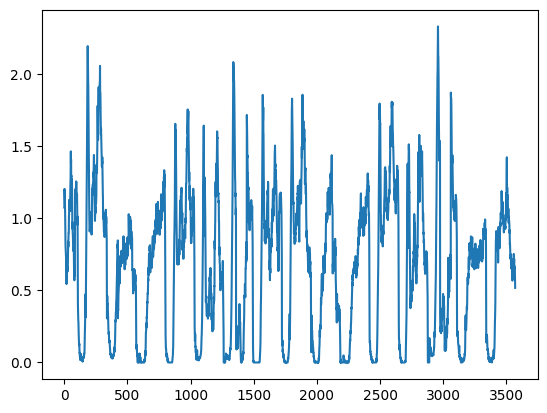

In [25]:
plt.plot(shared_capacity_test.sum(axis=1))

In [59]:
aaaa = np.load('/home/sergi_alcala/sergi_data/AZTEC_extension/Results_Optimal_Cities_test_kr_ki_ALLOC_changed/Paris/PHI_0.1/ETA_100/Block_2_3_results/ppf_static_0.9_ppf_helper_0.7/Th_85/raw_data_Results_Optimal_Cities_test_kr_ki_ALLOC_changed_alpha_2/output_norm.npy')

In [61]:
bbb = np.load('/home/sergi_alcala/sergi_data/AZTEC_extension/Results_Optimal_Cities_test_kr_ki_ALLOC_changed/Paris/PHI_0.1/ETA_100/Block_2_3_results/ppf_static_0.9_ppf_helper_0.7/Th_85/shared_fore_uncer_block2_delay_85_phi_0.1_alpha_2_gamma_2.npy')

In [64]:
def montecarlo_stuff(static_val,ppf_val=0.7):
    static_val = static_val.clip(min=0)
                    
            # # Save results of the test model with validation dataset 
            


    dist_load_forecasted = scipy.stats.norm(loc=static_val.mean(axis=-1),
                                        scale=static_val.std(axis=-1))


    # upper_load_forecasted = dist_load_forecasted.ppf(0.7) 
    upper_load_forecasted = dist_load_forecasted.ppf(ppf_val) 

    upper_load_forecasted[np.where(np.isnan(upper_load_forecasted))] = (
    static_val[np.where(np.isnan(upper_load_forecasted))][:, 0])
    return upper_load_forecasted

In [65]:
bbb_mt = montecarlo_stuff(bbb, 100)

/home/sergi_alcala/anaconda3/envs/AZTEC_ext/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2244: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/sergi_alcala/anaconda3/envs/AZTEC_ext/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2245: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


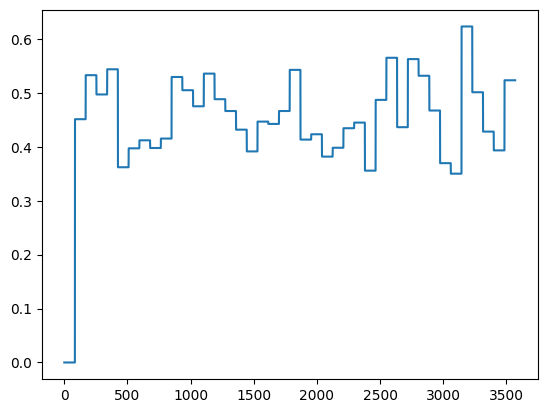

In [66]:
plt.plot(bbb_mt)

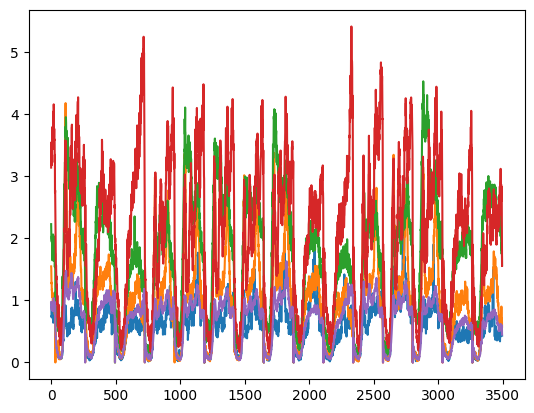

In [60]:
plt.plot(aaaa)

In [100]:
upper_static_test = 

(3570, 5)

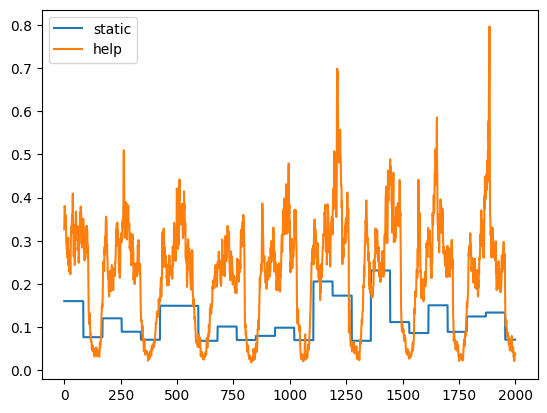

In [84]:
plt.plot(upper_static_test[start:end,0], label = 'static')
plt.plot(upper_help_test[start:end,0], label = 'help')
plt.legend()

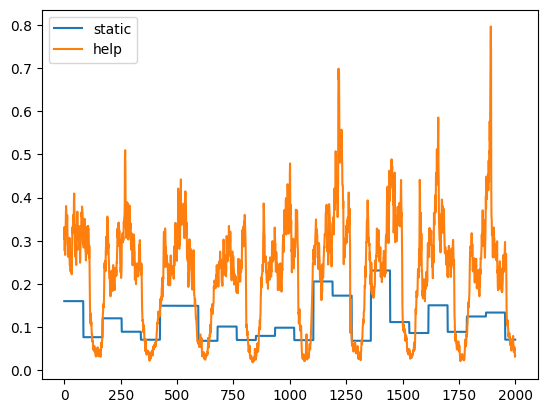

In [59]:
plt.plot(upper_static_test[start:end,0], label = 'static')
plt.plot(upper_help_test[start:end,0], label = 'help')
plt.legend()

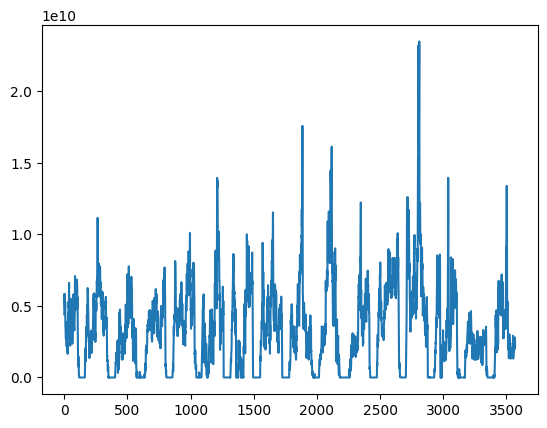

In [87]:
plt.plot(shared_capacity_test_den[:,0])

In [69]:
agg_shared_capacity_training_norm =agg_minmaxscaler.fit_transform(shared_capacity_training_den.sum(axis=-1).reshape(-1, 1))
agg_shared_capacity_test_norm =agg_minmaxscaler.transform(shared_capacity_test_den.sum(axis=-1).reshape(-1, 1))

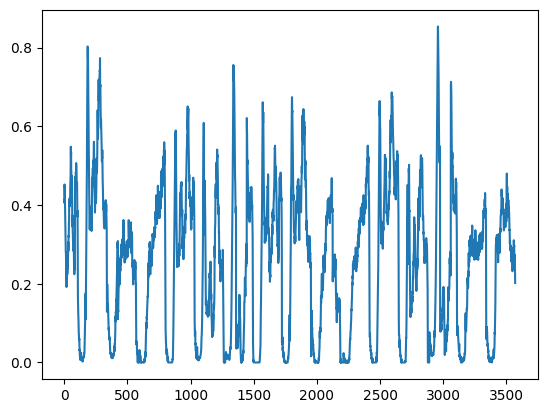

In [70]:
plt.plot(agg_shared_capacity_test_norm)

In [67]:
    
########################################

agg_minmaxscaler = MinMaxScaler()
agg_shared_capacity_training = tf.convert_to_tensor(agg_minmaxscaler.fit_transform(shared_capacity_training_den.sum(axis=-1).reshape(-1, 1)),
                                                    dtype=tf.float32)
agg_shared_capacity_test = tf.convert_to_tensor(agg_minmaxscaler.transform(shared_capacity_test_den.sum(axis=-1).reshape(-1, 1)),
                                            dtype=tf.float32)

2024-04-06 10:19:04.121628: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79078 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0
2024-04-06 10:19:04.123736: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79078 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:81:00.0, compute capability: 8.0
2024-04-06 10:19:04.125385: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79078 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:e2:00.0, compute capability: 8.0


In [98]:

    
        


        # if save:
        #     if not os.path.exists(f'./sergi_data/AZTEC_extension/{save_folder}/{city}/PHI_{PHI}/ETA_{ETA}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{DELAY}'):
        #         os.makedirs(f'./sergi_data/AZTEC_extension/{save_folder}/{city}/PHI_{PHI}/ETA_{ETA}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{DELAY}')
        #     pickle.dump(agg_minmaxscaler, open(f'./sergi_data/AZTEC_extension/{save_folder}/{city}/PHI_{PHI}/ETA_{ETA}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{DELAY}/block_2_minmaxscaler.pkl', 'wb'))

input_dataset = keras.preprocessing.timeseries_dataset_from_array(agg_shared_capacity_training[:-DELAY], None,
                                                                sequence_length=LOOKBACK, sequence_stride=DELAY)
target_dataset = keras.preprocessing.timeseries_dataset_from_array(agg_shared_capacity_training[LOOKBACK:], None,
                                                                sequence_length=DELAY, sequence_stride=DELAY)

test_dataset = keras.preprocessing.timeseries_dataset_from_array(agg_shared_capacity_test[:-DELAY], None,
                                                                sequence_length=LOOKBACK, sequence_stride=DELAY,
                                                                batch_size=128)
model = NN.make_model_lstm_block2(LOOKBACK)

optimizer = Adam(learning_rate=0.0005)


print(f' City: {city} - Phi: {PHI} - Alpha: {ALPHA} - Delay: {DELAY} - Gamma: {GAMMA} - Lookback: {LOOKBACK}')
for epoch in tqdm(range(EPOCHS)):
#print("\nStart of epoch %d" % (epoch,))
    for step, (x_batch_train, y_batch_train) in enumerate(zip(input_dataset, target_dataset)):
            

            with tf.GradientTape() as tape:
            
                prediction = model(x_batch_train, training=True)
                loss_value = cost_func(y_batch_train, prediction, ALPHA, DELAY, GAMMA)
        
            grads = tape.gradient(loss_value, model.trainable_weights)
            optimizer.apply_gradients(zip(grads, model.trainable_weights))

load_forecasted = np.zeros((int(agg_shared_capacity_test.shape[0]/DELAY), B))

for idx, inputs in enumerate(test_dataset):
    for i in range(B):
        if inputs.shape[0] == 128:
            load_forecasted[idx * 128: (idx+1)*128, i] = model.predict(inputs,verbose=0)[:, 0]
        else:
            load_forecasted[-inputs.shape[0]:, i] = model.predict(inputs,verbose=0)[:, 0]



    
load_forecasted = np.repeat(load_forecasted, DELAY, axis=0)


IndentationError: expected an indented block after 'for' statement on line 22 (1099439980.py, line 25)